# Pima Indians Diabetes Random Forest 분류

## 개요
- Random Forest Classifier를 활용한 당뇨병 예측
- GridSearchCV로 하이퍼파라미터 최적화
- 피처 중요도 분석 및 시각화

## Random Forest 특징
- 스케일링 불필요 (거리 기반 아님)
- 자체 피처 중요도 산출 (Gini Importance)
- 과적합 방지 (앙상블 효과)

## 주요 단계
1. 데이터 로드 및 분리
2. GridSearchCV 하이퍼파라미터 탐색
3. 최적 모델 평가
4. 피처 중요도 분석

## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [17]:
data = load_breast_cancer()
data
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts(normalize=True)}")

데이터 크기: (569, 30)
피처 목록: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

클래스 분포:
1    0.627417
0    0.372583
Name: proportion, dtype: float64


**데이터 샘플 확인**

In [18]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0  

**학습/테스트 데이터 분리**

In [19]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest 클래스 분포:\n{y_test.value_counts(normalize=True)}")

Train: (455, 30), Test: (114, 30)

Train 클래스 분포:
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test 클래스 분포:
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## 2. Random Forest Classifier

**Random Forest 특징**
- 스케일링 불필요: 거리 기반이 아닌 트리 기반
- 피처 중요도: Gini Importance 자동 계산
- 과적합 방지: 다수의 트리 앙상블
- 비선형 관계 학습 가능

**하이퍼파라미터**
- n_estimators: 트리 개수
- max_depth: 트리 최대 깊이 (과적합 방지)
- min_samples_split: 노드 분할 최소 샘플
- min_samples_leaf: 리프 노드 최소 샘플

**모델 및 하이퍼파라미터 그리드 설정**

In [20]:
# Random Forest 모델
rf_clf = RandomForestClassifier(random_state=42)

# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Random Forest Classifier 생성")
print(f"\n파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

Random Forest Classifier 생성

파라미터 그리드:
  n_estimators: [100, 200]
  max_depth: [None, 10, 20]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]

총 조합 수: 24개


## 3. GridSearchCV 하이퍼파라미터 탐색

**GridSearchCV 설정**
- cv: StratifiedKFold(5) - 클래스 비율 유지
- scoring: accuracy
- n_jobs=-1: 모든 CPU 코어 사용

In [21]:
# GridSearchCV
print("Tuning RandomForest Classifier...")
print("(교차검증 수행 중...)\n")

grid_clf = GridSearchCV(
    rf_clf,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train, y_train)
print("\nGridSearchCV 완료!")

Tuning RandomForest Classifier...
(교차검증 수행 중...)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [16]:
# 최적 모델 추출
best_clf = grid_clf.best_estimator_

print("[최적화 결과]")
print(f"Best Accuracy (Train CV): {grid_clf.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_clf.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best Accuracy (Train CV): 0.9604

Best Parameters:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200


**GridSearchCV 상위 결과**

In [22]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_clf.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators param_max_depth  param_min_samples_split  param_min_samples_leaf  mean_test_score  std_test_score
                200            None                        2                       1         0.960440        0.019160
                200              10                        2                       1         0.960440        0.019160
                200              20                        2                       1         0.960440        0.019160
                100            None                        2                       2         0.956044        0.025059
                200            None                        5                       2         0.956044        0.025059


## 5. 테스트 데이터 평가

**예측 및 성능 평가**

In [23]:
# 테스트 데이터 예측
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9561

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**Confusion Matrix 시각화 (선택사항)**

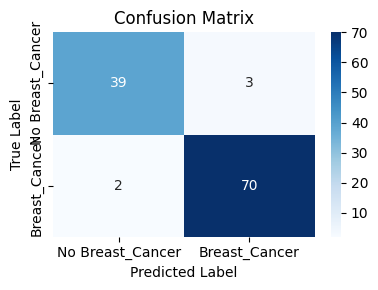

In [27]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Breast_Cancer', 'Breast_Cancer'],
            yticklabels=['No Breast_Cancer', 'Breast_Cancer'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**Gini Importance**
- 각 피처가 불순도를 얼마나 감소시키는지 측정
- 값이 클수록 중요한 피처
- Random Forest 자체 계산 (별도 분석 불필요)

In [25]:
# 피처 중요도 추출
importances = best_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
                Feature  Importance
        worst perimeter    0.133100
             worst area    0.128052
   worst concave points    0.108107
    mean concave points    0.094414
           worst radius    0.090639
            mean radius    0.058662
         mean perimeter    0.055242
              mean area    0.049938
         mean concavity    0.046207
        worst concavity    0.035357
             area error    0.034368
       mean compactness    0.018094
          worst texture    0.017869
      worst compactness    0.014481
           mean texture    0.014317
       worst smoothness    0.014026
           radius error    0.013454
         worst symmetry    0.009570
        perimeter error    0.008138
        concavity error    0.007136
worst fractal dimension    0.006387
        mean smoothness    0.006168
          texture error    0.005441
          mean symmetry    0.005004
      compactness error    0.004630
         symmetry error    0.004611
 mean fractal di

**피처 중요도 시각화**

/tmp/ipykernel_811/1131470680.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


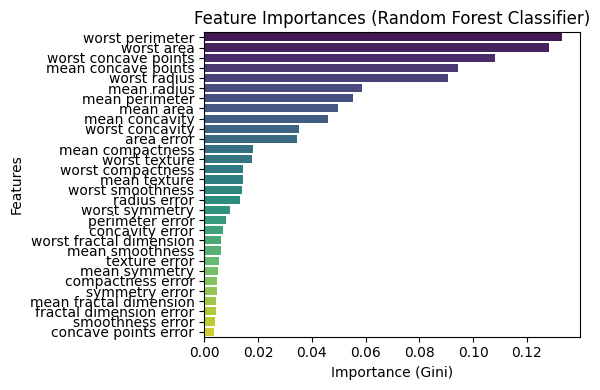

In [28]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (Random Forest Classifier)")
plt.xlabel("Importance (Gini)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 7. 상위 피처만 사용한 모델 비교

**상위 5개 피처로 재학습**

In [29]:
# 상위 5개 피처 선택
top_5_features = feature_names[indices[:5]]
print(f"상위 5개 피처: {list(top_5_features)}")

# 상위 피처만으로 학습
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

rf_top5 = RandomForestClassifier(**grid_clf.best_params_, random_state=42)
rf_top5.fit(X_train_top5, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5)
accuracy_top5 = accuracy_score(y_test, y_pred_top5)

# 비교
print("\n성능 비교:")
print(f"모든 피처 (8개): Accuracy = {test_accuracy:.4f}")
print(f"상위 5개 피처: Accuracy = {accuracy_top5:.4f}")
print(f"\n정확도 차이: {test_accuracy - accuracy_top5:+.4f}")

상위 5개 피처: ['worst perimeter', 'worst area', 'worst concave points', 'mean concave points', 'worst radius']

성능 비교:
모든 피처 (8개): Accuracy = 0.9561
상위 5개 피처: Accuracy = 0.9298

정확도 차이: +0.0263
